In [3]:
import pandas as pd
df = pd.read_csv("Dataset/liver_cirrhosis/liver_cirrhosis.csv")
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,C,Placebo,18499,F,N,Y,N,N,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,C,Placebo,19724,M,Y,N,Y,N,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,C,Placebo,11839,F,N,N,N,N,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,D,Placebo,16467,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,D,Placebo,21699,F,N,Y,N,N,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


In [4]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# 0. Load and basic clean
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces from column names

# 1. Choose features to keep and map categorical values
features_to_keep = [
    'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema',
    'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT',
    'Tryglicerides', 'Platelets', 'Prothrombin'
]
target_col = 'Stage'

# 2. Age conversion (days to years)
df['Age'] = (df['Age'] / 365).round(2)

# 3. Categorical mapping
df['Sex'] = df['Sex'].map({'F': 0, 'M': 1})
df['Ascites'] = df['Ascites'].map({'N': 0, 'Y': 1})
df['Hepatomegaly'] = df['Hepatomegaly'].map({'N': 0, 'Y': 1})
df['Spiders'] = df['Spiders'].map({'N': 0, 'Y': 1})
df['Edema'] = df['Edema'].map({'N': 0, 'S': 1, 'Y': 2})  # You can use {'N':0, 'S':1, 'Y':1} for binary
df['Stage'] = df['Stage'].map({1: 0, 2: 1, 3: 2})

# 4. Split X and y
X = df[features_to_keep].copy()
y = df[target_col].copy()

# 5. Impute numerics (on the whole X for true duplicate detection)
num_cols = X.select_dtypes('number').columns
imp = SimpleImputer(strategy='median')
X[num_cols] = imp.fit_transform(X[num_cols])

# 6. Drop exact-feature duplicates (on both X and y)
dups = X.duplicated(keep=False)
print(f"Dropping {dups.sum()} rows that are exact-feature dups")
X = X.loc[~dups].reset_index(drop=True)
y = y.loc[~dups].reset_index(drop=True)

# 7. Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 8. Print summary
print("Final deduplicated dataset shape:", X.shape)
print("Number of labels (after deduplication):", y.shape)
print("Train set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())


Dropping 18342 rows that are exact-feature dups
Final deduplicated dataset shape: (6658, 15)
Number of labels (after deduplication): (6658,)
Train set shape: (5326, 15) (5326,)
Test set shape: (1332, 15) (1332,)
Train class counts:
 Stage
2    1890
1    1802
0    1634
Name: count, dtype: int64
Test class counts:
 Stage
2    472
1    451
0    409
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier



param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}




xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=30,  # You can increase this for deeper search
    scoring='f1_macro',  # Or 'roc_auc' if you want AUC
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best F1 Score on CV:", random_search.best_score_)

from sklearn.metrics import classification_report, confusion_matrix

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=3, n_estimators=150, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=3, n_estimators=150, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=1.0, gamma=0, learning_rate=0.1, max_depth=3, n_estimators=150, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.1, max_depth=7, n_estimators=100, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.1, max_depth=7, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.6, gamma=0.3, learning_rate=0.1, max_depth=7, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.05, max_depth=7, n_estimators=150, subsample=0.6; total time=   0.4s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.05, 

Confusion Matrix:
 [[360  38  11]
 [ 25 407  19]
 [ 11  32 429]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89       409
           1       0.85      0.90      0.88       451
           2       0.93      0.91      0.92       472

    accuracy                           0.90      1332
   macro avg       0.90      0.90      0.90      1332
weighted avg       0.90      0.90      0.90      1332

Macro ROC-AUC: 0.9721


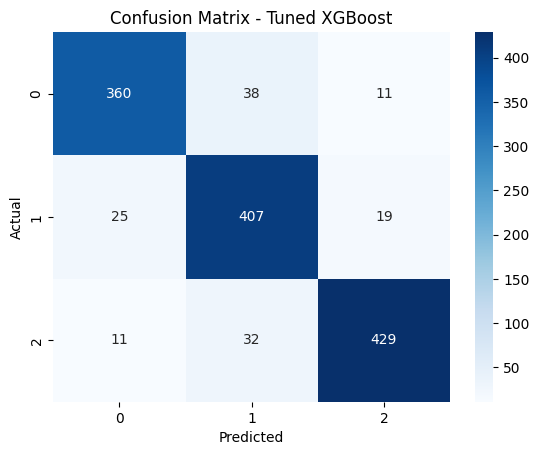

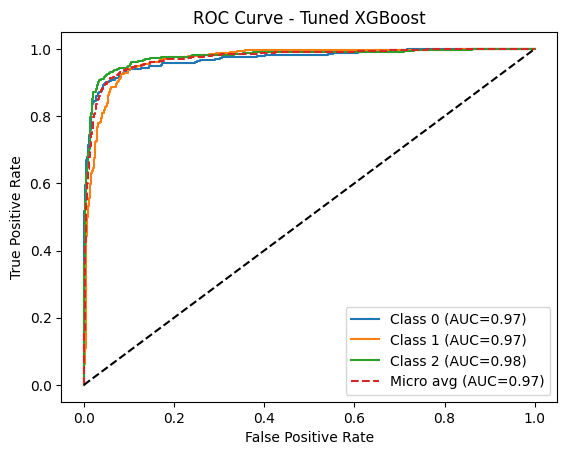

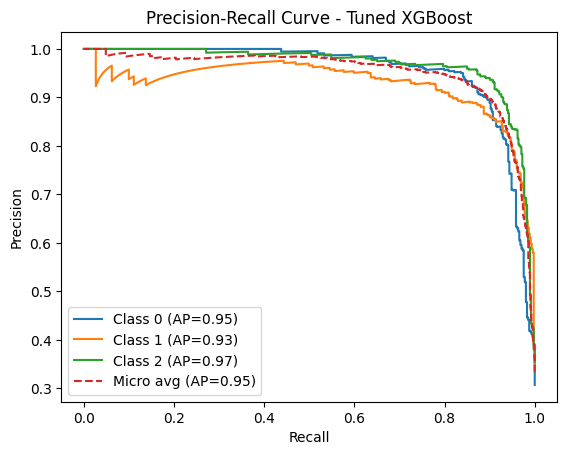

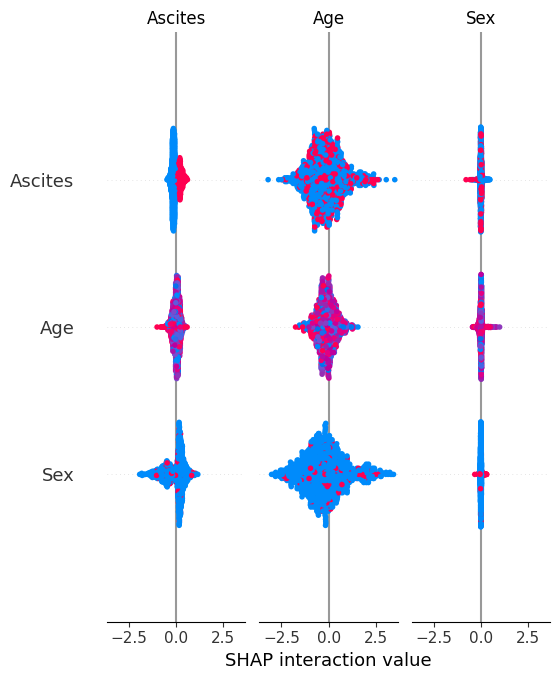

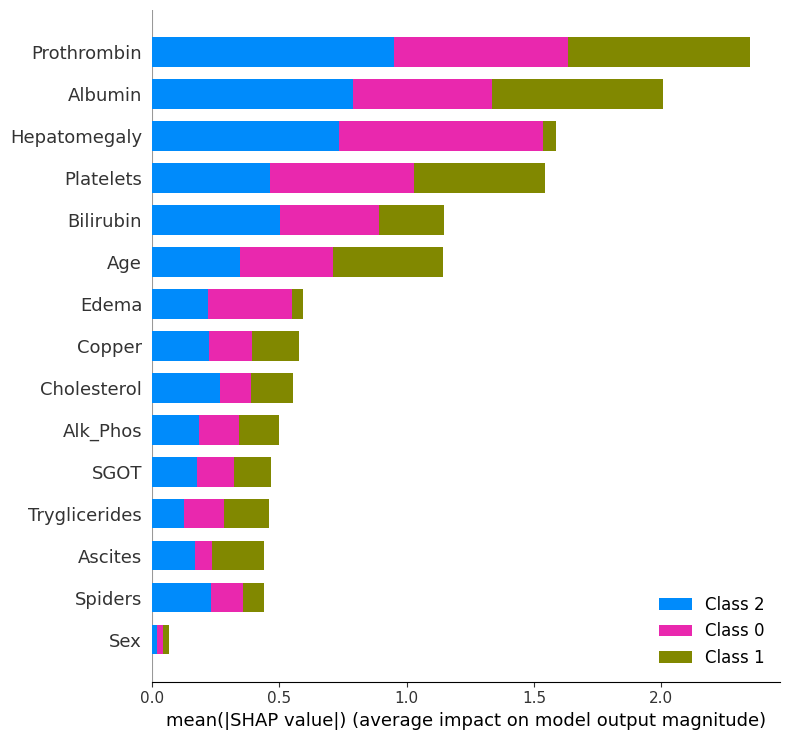

In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

# ---- Train final model with your best params ----
final_xgb = XGBClassifier(
    eval_metric='mlogloss',
    random_state=42,
    subsample=0.8,
    n_estimators=200,
    max_depth=7,
    learning_rate=0.3,
    gamma=0,
    colsample_bytree=1.0
)
final_xgb.fit(X_train, y_train)

# ---- Predict & basic report ----
y_pred = final_xgb.predict(X_test)
y_proba = final_xgb.predict_proba(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---- Macro ROC-AUC (OvR) ----
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
print(f"Macro ROC-AUC: {auc_macro:.4f}")

# ---- Confusion matrix plot ----
plt.figure()
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

# ---- ROC & PR curves (per-class + micro) ----
classes = np.unique(y_test)
y_bin = label_binarize(y_test, classes=classes)

# ROC
fpr, tpr, roc_auc = {}, {}, {}
for i, c in enumerate(classes):
    fpr[c], tpr[c], _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc[c] = auc(fpr[c], tpr[c])

fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure()
for c in classes:
    plt.plot(fpr[c], tpr[c], label=f"Class {c} (AUC={roc_auc[c]:.2f})")
plt.plot(fpr["micro"], tpr["micro"], linestyle='--', label=f"Micro avg (AUC={roc_auc['micro']:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned XGBoost"); plt.legend(); plt.show()

# PR
precision, recall, pr_auc = {}, {}, {}
for i, c in enumerate(classes):
    precision[c], recall[c], _ = precision_recall_curve(y_bin[:, i], y_proba[:, i])
    pr_auc[c] = average_precision_score(y_bin[:, i], y_proba[:, i])

precision["micro"], recall["micro"], _ = precision_recall_curve(y_bin.ravel(), y_proba.ravel())
pr_auc["micro"] = average_precision_score(y_bin, y_proba, average="micro")

plt.figure()
for c in classes:
    plt.plot(recall[c], precision[c], label=f"Class {c} (AP={pr_auc[c]:.2f})")
plt.plot(recall["micro"], precision["micro"], linestyle='--', label=f"Micro avg (AP={pr_auc['micro']:.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned XGBoost"); plt.legend(); plt.show()

# ---- SHAP (TreeExplainer) ----
explainer = shap.TreeExplainer(final_xgb)
# check_additivity=False is sometimes needed to avoid warnings with XGB>=1.6
shap_values = explainer.shap_values(X_test, check_additivity=False)

# Beeswarm & bar per class
if isinstance(shap_values, list):  # XGBoost returns list per class
    for i, sv in enumerate(shap_values):
        print(f"SHAP summary for class {i}")
        shap.summary_plot(sv, X_test, show=True)  # beeswarm
        shap.summary_plot(sv, X_test, plot_type="bar", show=True)
else:
    shap.summary_plot(shap_values, X_test, show=True)
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

